# Többdimenziós dinamikai számítások numerikus közelítéssel

## Fizika informatikusoknak géptermi gyakorlat

### v 2026/0.95

In [1]:
from fizinfo import *

import numpy as np    
import matplotlib.pyplot as plt
%matplotlib inline    

# Ferde hajítás 2D-ben

Közegellenállás nélküli és közegellenállásos eset összehasonlítása.

***Egy testet 20 m magasról, 16 m/s nagyságú, a vízszintessel 42 fokos szöget bezáró irányban eldobunk.***
 
Ezt numerikus kinematikával már megoldottuk!
 

In [ ]:
# ***Egy testet 20 m magasról, 16 m/s nagyságú, a vízszintessel 42 fokos szöget bezáró irányban eldobunk.***
#  
# Ezt numerikus kinematikával már megoldottuk!

# Bemenő adatok:
h=20.0
v0_abs=16.0
alpha_deg=42.0
g=9.81

# Kezdőértékek koordinátái
v0_x=v0_abs*np.cos(np.radians(alpha_deg))
v0_y=v0_abs*np.sin(np.radians(alpha_deg))

x0=0.0
y0=h

## Első modell: csak gravitációs erő, nincs közegellenállás

Ez visszaadja a kinematikai módszerrel kapható megoldást.

In [3]:
# EZ A LÉNYEGI RÉSZ!
# Itt adjuk meg a rendszer erőfüggvényét és tömeg-idő függvényét.
# A későbbiekben itt közegellenállást, majd rakétahajtást is hozzáadunk az erőfüggvényhez:
#    ebből következik majd a más viselkedés.
# Megjegyzés: a tömeg többnyire konstans, de nem mindig. Lásd az óra végi rakéta-modellt.

def create_grav_F_m(m, g=9.81):

    # konstans tömeg
    def mass_fun(t):   # formai okokból kell a t de ettől nem függ ez a tömeg
        return m

    def force_fun(t, r, v, m):  # formai okokból kell a t, r, v de egyiktől sem függ ez az erőfüggvény
        return np.array([0.0, -m*g], np.float64)  # egyszerű, lefele mutató m*g nagyságú erő

    return force_fun, mass_fun

F_grav, m_const = create_grav_F_m(0.45)

In [ ]:
ball_din=num_dinam(2)                       # objektum létrehozás
ball_din.set_time_range(0.0, 4.0, 0.01)     # időintervallum
ball_din.set_mass_fun(m_const)              # tömeg beállítás
ball_din.set_F_fun(F_grav)                  # erőfüggvény beállítása
ball_din.set_r0_v0([x0, y0], [v0_x, v0_y])  # kezdő hely és sebesség beállítása

ball_din.full_dinam_calc()   # a dinamikai számítások végrehajtása

ball_din.plot_rcomp(figsize=(7,7))        # pálya plottolás

In [5]:
ball_din.full_dinam_calc()   # a dinamikai számítások végrehajtása

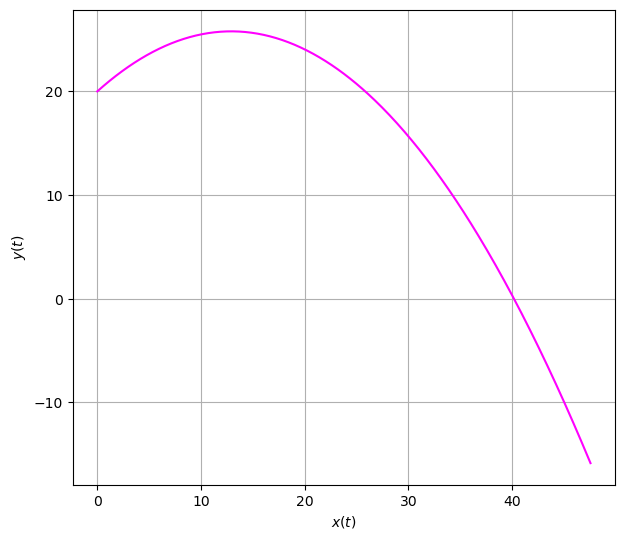

In [6]:
ball_din.plot_rcomp(figsize=(7,7))        # pálya plottolás

Akit érdekel, összehasonlíthatja a numerikus kinematikában tanultakkal! Ugyanaz a megoldás.

De a dinamikai megközelítésnek vannak előnyei:

### Leállási feltétel megadása

In [7]:
# Egyszerű leállási feltétel: ha y<0, akkor stop
def stop_ground_y(r, v):
    """Leállás y<0 esetén"""
    
    return r[1]<0.0

In [ ]:
# Egyszerű leállási feltétel: ha y<0, akkor stop
def stop_ground_y(r, v):
    """Leállás y<0 esetén"""
    
    return r[1]<0.0

# ugyanaz, mint előbb: ...
ball_din=num_dinam(2)
ball_din.set_time_range(0.0, 4.0, 0.01)
# erő- és tömegfüggvény
ball_din.set_mass_fun(m_const)
ball_din.set_F_fun(F_grav)
# kezdőfeltétel
ball_din.set_r0_v0([x0, y0], [v0_x, v0_y])

# itt jön a leállási feltétel specifikálása:
ball_din.set_stop_cond(stop_ground_y)   # a fenti függvény megadása

# dinamikai számítások
ball_din.full_dinam_calc()

ball_din.plot_rcomp(figsize=(7,7))

In [9]:
# dinamikai számítások
ball_din.full_dinam_calc()

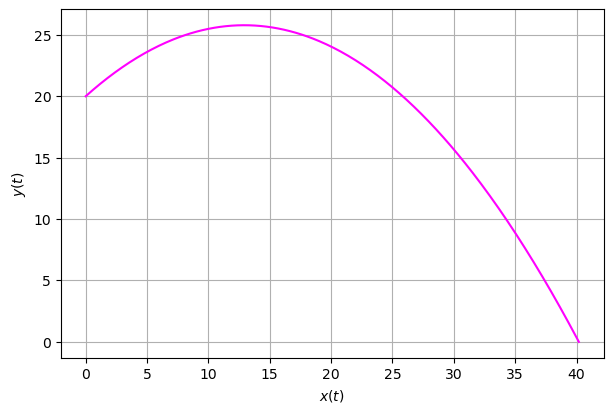

In [10]:
ball_din.plot_rcomp(figsize=(7,7))

Látható: a test földbe csapódásakor megállt a számolás! Ezt a kinematikai megközelítés nem tudja kezelni.

## Második modell: gravitáció + közegellenállás

Számoljuk ki az előző dobást úgy, mintha focilabdával történne!

Szabvány: m=410--450 g; kerület: 68--70 cm.

In [11]:
# Ez a lényeg! Milyen erők hatnak egy focilabdára? Gravitáció + közegellenállás.

def create_grav_közeg_F_m(m, C, A, rho, g=9.81):
    """Egy konstans tömegű test tömege és a rá ható erő gravitációs tér és közegellenállás jelenlétében."""
    
    # konstans tömeg
    def mass_fun(t):   # formai okokból kell a t de ettől nem függ ez a tömeg
        return m

    def force_fun(t, r, v, m):  # itt már függ az erő a sebességtől
        """Gravitációs erő y irányban és v^2-tel arányos közegellenállási erő eredője."""
        
        F_work=np.array([0.0, -m*g], np.float64)  # grav erő
        v_abs=((v**2).sum())**0.5
        F_work-=0.5*C*A*rho*v*v_abs # közegell. erő hatása
    
        return F_work

    return force_fun, mass_fun

In [12]:
# most meghívjuk adott paraméterekkel:

m_soccer=0.43      # focilabda közepes tömeg
perim_soccer=0.69  # focilabda közepes kerület

r=perim_soccer/(2*np.pi)
A=np.pi*r**2  # mozgásirányú keresztmetszet
C=0.47     # gömb
rho=1.3    # levegő sűrűség
g=9.81

# legeneráljuk az erő és tömegfüggvényeket:
F_soccer, m_soccer = create_grav_közeg_F_m(m_soccer, C, A, rho, g)

In [13]:
# innentől ugyanaz a számítás, mint előbb:

ball_k_din=num_dinam(2)
ball_k_din.set_time_range(0.0, 4.0, 0.01)
# itt a változás!
ball_k_din.set_mass_fun(m_soccer)
ball_k_din.set_F_fun(F_soccer)     

# kezdőfeltétel
ball_k_din.set_r0_v0([x0, y0], [v0_x, v0_y])
# leállási feltétel
ball_k_din.set_stop_cond(stop_ground_y)
# dinamikai számítások
ball_k_din.full_dinam_calc()

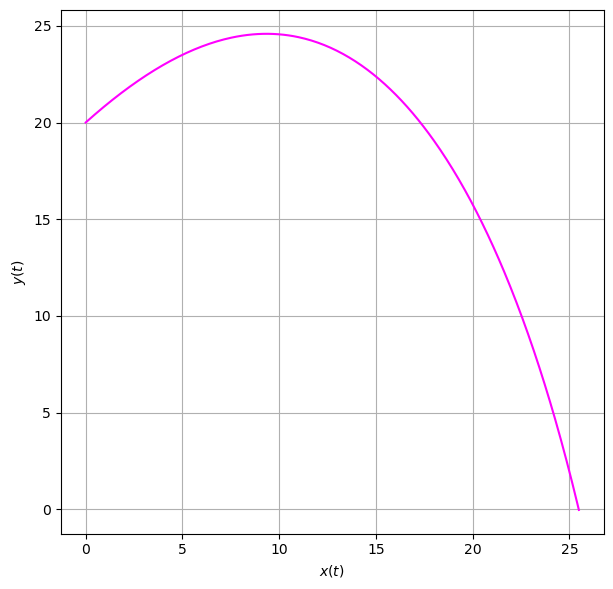

In [14]:
ball_k_din.plot_rcomp(figsize=(7,7))

In [15]:
# Sokkal kisebb a megtett távolság, mint közegellenállás nélkül!

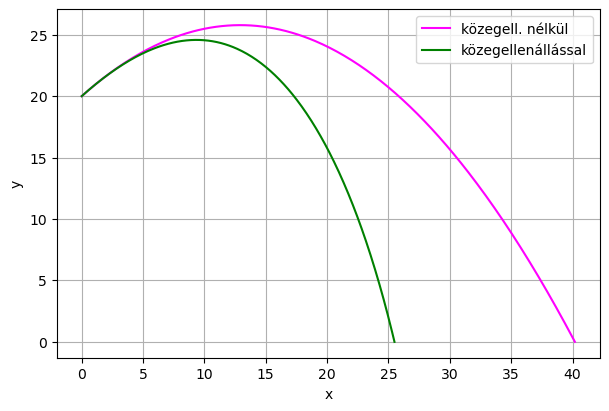

In [16]:
# Jobb összehasonlítás: egyetlen plot-ra mindkét esetet:

fig=plt.figure(figsize=(7,7))  

ax1=fig.add_subplot(111) 

ax1.plot(ball_din.r[:,0], ball_din.r[:,1], color="magenta", label="közegell. nélkül")
ax1.plot(ball_k_din.r[:,0], ball_k_din.r[:,1], color="green", label="közegellenállással")
ax1.set_xlabel("x") 
ax1.set_ylabel("y") 
ax1.legend(loc="best")
ax1.grid()    

ax1.set_aspect(aspect='equal')

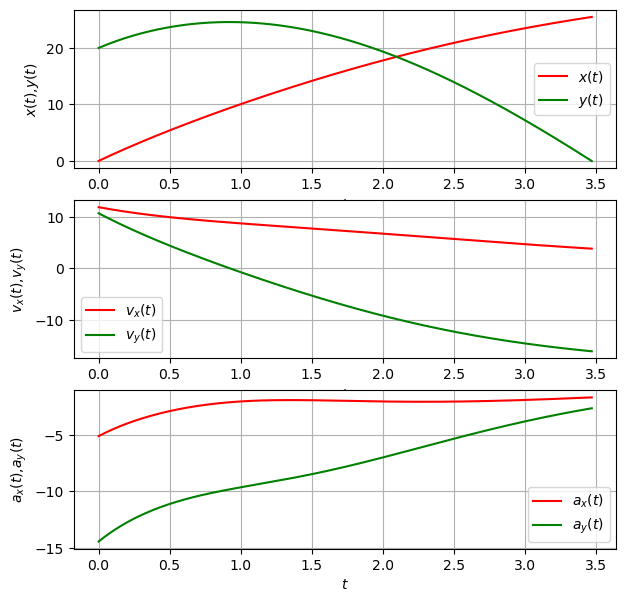

In [17]:
# komponensek az idő függvéyében:
ball_k_din.plot_rva_coord(figsize=(7,7))

Látható, hogy pl. a gyorsulás nem konstans, az x irányú sebesség csökken, stb.

### Mikor és hol volt a test a legmagasabban?

In [18]:
# Legmagasabb: y koordináta maximális.

y_work=ball_k_din.r[:,1] # ez a test y-koordinátája az idő függvényében

arg_ymax=y_work.argmax()

print("A legmagasabb pont:")
print(f"    ideje: {ball_k_din.t[arg_ymax]:.2f} s")
print(f"    helye: x={ball_k_din.r[arg_ymax,0]:.2f}; x={ball_k_din.r[arg_ymax,1]:.2f} m")

A legmagasabb pont:
    ideje: 0.92 s
    helye: x=9.35; x=24.59 m


### Mikor és hol csapódott a földbe?

In [19]:
# földbe csapódás: y=0
# előző y_work felhasználásával

becsap_args=arg_eq(y_work, 0.0)

# Akár több megoldás is lehetne más mozgásnál!

print(f"A test a talajszintet {len(becsap_args)} alkalommal éri el.")
print("Ezek adatai:")
for arg in becsap_args:
    print(f"   idő: {ball_k_din.t[arg]:.2f} s\tx: {ball_k_din.r[arg, 0]:7.2f}\ty: {ball_k_din.r[arg,1]:7.2f}")

A test a talajszintet 1 alkalommal éri el.
Ezek adatai:
   idő: 3.46 s	x:   25.45	y:    0.14


### Mekkora volt a becsapódás sebessége?

In [20]:
v_abs_work=vect_abs(ball_k_din.v)

print(f"A test a talajszintet {len(becsap_args)} alkalommal éri el.")
print("Ezek sebességei:")
for arg in becsap_args:
    print(f"   |v|: {v_abs_work[arg]:7.2f}")

A test a talajszintet 1 alkalommal éri el.
Ezek sebességei:
   |v|:   16.50


### Gyakorlás a régi eszközökkel

(arg_eq, calc_pathlength, ...)

   * Mikor, hol és milyen sebességgel érte el a kezdetnél 1 m-rel magasabbi szintet?
   * Mennyi utat tett meg a becsapódásig?
   * Mikor volt az a pillanat, amikor 20 m útnál tartott a test?
   * Ha a házzal szemben, tőle 15 m-rel egy másik, magas ház lenne, azt milyen magasan érné el a test?¶

##  A régi szabadrúdásos példa közegellenállással

Egy focimeccsen szabadrúgás következik 30 m-re a kaputól, szemből. A játékos
120 km/h kezdősebességgel rúgja el a labdát, a vízszintessel 12˚-os szöget bezáróan.
   * Ha a labda nem akad el a sorfalban, akkor mikor éri el a kapu vonalát?
   * Fölé megy-e a labda a 2,44 m magas kapunak?
   * Mi a labda maximális magassága a repülés közben?
   * Ha áll egy sorfal 9 m-re az ellövés helyétől, akkor ott milyen magasan lesz a labda?
   
Számoljunk ezúttal a közegellenállással is!

In [21]:
# Ugyanúgy, mint az előbb!

# m_soccer() és F_soccer() megörökölve korábbról

# kezdőértékek
v0=120/3.6
alpha_deg=12.0

x0=0.0
y0=0.0
v0_x=v0*np.cos(np.radians(alpha_deg))
v0_y=v0*np.sin(np.radians(alpha_deg))


# dinamikai számítások
soccer_din=num_dinam(2)
soccer_din.set_time_range(0.0, 4.0, 0.01)
soccer_din.set_mass_fun(m_soccer)
soccer_din.set_F_fun(F_soccer)   
soccer_din.set_r0_v0([x0, y0], [v0_x, v0_y])

soccer_din.stop_cond=stop_ground_y

soccer_din.full_dinam_calc()

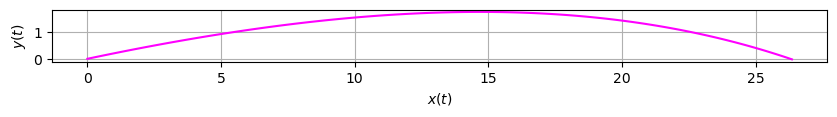

In [22]:
soccer_din.plot_rcomp()

In [23]:
# Milyen magasan éri el a kaput?

arg_goal=arg_eq(soccer_din.r[:,0], 30.0)  # ennél/ezeknél az indexnél éri el a kaput

print(f"A kaput a labda {len(arg_goal)} alkalommal éri el.")
for i_goal in arg_goal:
    y_goal=soccer_din.r[i_goal, 1]          # ennél a magasságnál éri el a kaput
    t_goal=soccer_din.t[i_goal]
    print(f"  -- magasság: {y_goal:.2f} m;  időpont: {t_goal:.2f} s.")


A kaput a labda 0 alkalommal éri el.


In [24]:
# Ajaj!!
# Ennyit számít a közegellenállás!
# A legtöbbször, amikor egy fizika-példában elhanyagoljuk a közegellenállást, jelentős hibát követünk el.

### 1. feladat:

Keressünk olyan ellövési paramétereket, hogy a labda kb 2 m magasan találja el a kaput!

## Lövés-táblázat és grafikon készítése

Az előző szabadrúgásos példa alapján:

a) Írjunk függvényt, mely kiszámolja tetszőleges `v0` sebesség és `alpha` szög esetében elrúgott focilabda repülési távolságát és maximális magasságát.

b) Az előző függvény segítségével készítsünk "lőtáblázatot" `v0=120 km/h` esetére `alpha` 0 és 90 fok közt 2 fokonként változtatott értékeire.

c) Készítsünk grafikont az előző táblázat alapján, tehát a vízsszintes tengelyen `alpha` (fokban), a függőleges tengelyen a max. távolság és magasság szerepeljen (méterben).

In [25]:
# a)

# Mindent egy függvénybe pakolunk, de elvi újdonág nincs.

def soccer_ball_distance_height(v0, alpha, m_soccer=0.43, perim_soccer=0.69, rho=1.3, g=9.81):

    # talaj
    def stop_ground_y(r, v):
        """Leállás y<0 esetén"""
    
        return r[1]<0.0

    # paraméterek, erő- és tömegfüggvény előállítása
    r=perim_soccer/(2*np.pi)
    A=np.pi*r**2
    C=0.47 # gömb

    F_soccer, m_soccer = create_grav_közeg_F_m(m_soccer, C, A, rho, g)

    # kezőfeltételek
    x0=0.0
    y0=0.0
    v0_x=v0*np.cos(alpha)
    v0_y=v0*np.sin(alpha)

    # dinamikai számolás
    work_din=num_dinam(2)
    work_din.set_time_range(0.0, 10.0, 0.01)
    work_din.set_mass_fun(m_soccer)
    work_din.set_F_fun(F_soccer) 
    work_din.set_r0_v0([x0, y0], [v0_x, v0_y])
    
    work_din.set_stop_cond(stop_ground_y)
    
    work_din.full_dinam_calc()

    max_distance=work_din.r[-1,0]  # a becsapódáskor álltunk le
    max_height=work_din.r[:,1].max()

    return max_distance, max_height


In [26]:
# teszteljük:
d,h = soccer_ball_distance_height(120/3.6, np.radians(12))
print(f"Max távolság: {d:.2f} m;  max magasság: {h:.2f} m.")

Max távolság: 26.36 m;  max magasság: 1.75 m.


In [27]:
# b) 

# most jön a táblázat

print(f"alpha\td_max\th_max")
for alpha_deg in np.arange(2.0, 91.0, 2.0):
    v0_kmh=120
    v0=v0_kmh/3.6
    d,h=soccer_ball_distance_height(v0, np.radians(alpha_deg))
    print(f"{alpha_deg:4.1f}\t{d:6.2f}\t{h:6.2f}")

alpha	d_max	h_max
 2.0	  6.66	  0.06
 4.0	 12.27	  0.23
 6.0	 16.69	  0.50
 8.0	 20.40	  0.85
10.0	 23.71	  1.27
12.0	 26.36	  1.75
14.0	 28.75	  2.29
16.0	 30.78	  2.88
18.0	 32.61	  3.51
20.0	 34.13	  4.19
22.0	 35.50	  4.89
24.0	 36.60	  5.62
26.0	 37.47	  6.38
28.0	 38.30	  7.16
30.0	 38.91	  7.96
32.0	 39.31	  8.77
34.0	 39.60	  9.59
36.0	 39.78	 10.42
38.0	 39.77	 11.26
40.0	 39.72	 12.10
42.0	 39.43	 12.93
44.0	 39.11	 13.77
46.0	 38.61	 14.59
48.0	 37.96	 15.41
50.0	 37.26	 16.21
52.0	 36.41	 17.00
54.0	 35.41	 17.77
56.0	 34.32	 18.52
58.0	 33.12	 19.25
60.0	 31.83	 19.95
62.0	 30.40	 20.62
64.0	 28.88	 21.26
66.0	 27.22	 21.87
68.0	 25.47	 22.44
70.0	 23.60	 22.98
72.0	 21.63	 23.47
74.0	 19.55	 23.91
76.0	 17.39	 24.32
78.0	 15.13	 24.67
80.0	 12.78	 24.97
82.0	 10.34	 25.22
84.0	  7.84	 25.42
86.0	  5.26	 25.56
88.0	  2.65	 25.65
90.0	  0.00	 25.68


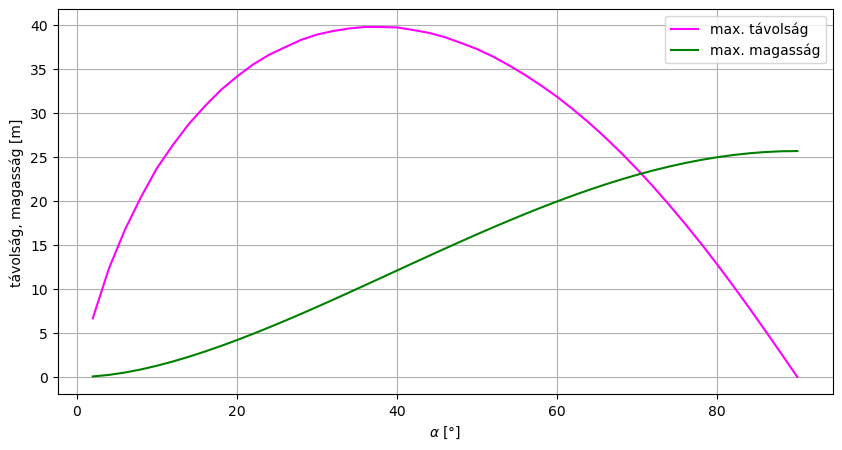

In [28]:
# c) 

# most jön a grafikon

# listákba pakoljuk az eredményeket:
alpha_deg_list=[]
d_max_list=[]
h_max_list=[]
for alpha_deg in np.arange(2.0, 91.0, 2.0):
    v0_kmh=120
    v0=v0_kmh/3.6
    d,h=soccer_ball_distance_height(v0, np.radians(alpha_deg))
    alpha_deg_list.append(alpha_deg)
    d_max_list.append(d)
    h_max_list.append(h)

# plottolunk:
fig=plt.figure(figsize=(10,5))  

ax1=fig.add_subplot(111) 

ax1.plot(alpha_deg_list, d_max_list, color="magenta", label="max. távolság")
ax1.plot(alpha_deg_list, h_max_list, color="green", label="max. magasság")
ax1.set_xlabel(r"$\alpha$ [°]") 
ax1.set_ylabel(r"távolság, magasság [m]") 
ax1.legend(loc="upper right")
ax1.grid()    

## 2. feladat:

a) A fenti példában szereplő labdát milyen szögben indítsuk, hogy a legmesszebbre repüljön? Mekkora ilyenkor a repülési távolság?

b) A fenti példában 20°-os induló szöggel számolva mi a legnagyobb és legkisebb repülési távolság szabványos focilabda esetén? A szabvány azt rögzíti, hogy a focilabda tömege 410 és 450 g között, kerülete 68 és 70 cm közt kell legyen.

## Szabadrúgás tervezése

Keressünk olyan ellövési paramétereket, hogy a labda kb 2 m magasan találja el a kaput földetérés nélkül!

Ne próba-szerencse módszerrel, hanem programozottan.

In [29]:
# függvény, mely alpha_deg, v0 párosra visszaadja a kapu eltalálásának magasságát
# d_goal: a kapu távolsága az ellővés helyétől
# az előző alapján, értelemszerű változásokkal

def soccer_ball_goal_height(v0, alpha, m_soccer=0.43, perim_soccer=0.69, rho=1.3, g=9.81, d_goal=30):

    # talaj
    def stop_ground_y(r, v):
        """Leállás y<0 esetén"""
    
        return r[1]<0.0

    # paraméterek, erő- és tömegfüggvény előállítása
    r=perim_soccer/(2*np.pi)
    A=np.pi*r**2
    C=0.47 # gömb

    F_soccer, m_soccer = create_grav_közeg_F_m(m_soccer, C, A, rho, g)

    # kezőfeltételek
    x0=0.0
    y0=0.0
    v0_x=v0*np.cos(alpha)
    v0_y=v0*np.sin(alpha)

    # dinamikai számolás
    work_din=num_dinam(2)
    work_din.set_time_range(0.0, 10.0, 0.001)
    work_din.set_mass_fun(m_soccer)
    work_din.set_F_fun(F_soccer) 
    work_din.set_r0_v0([x0, y0], [v0_x, v0_y])
    
    work_din.set_stop_cond(stop_ground_y)
    
    work_din.full_dinam_calc()
    
    # innentől különbözik az előző függvénytől
    ind_goal=arg_eq(work_din.r[:,0], d_goal)
    if len(ind_goal)==0:  # nem érte el a kaput
        h_goal=-1.0
    else:
        h_goal=work_din.r[ind_goal[0], 1]

    return h_goal



In [30]:
# kipróbáljuk:

# eredeti probléma
print(soccer_ball_goal_height(120/3.6, np.radians(12), d_goal=30))

# meredekebb szög
print(soccer_ball_goal_height(120/3.6, np.radians(18), d_goal=30))

-1.0
1.4560333181484157


In [31]:
# 12 fokos ellövéskor lepattan a kapu előtt, 18 fokosnál kb 1.3 m magasan találja el a kaput

In [32]:
# módszeresebb keresés a h_goal_0=2 m magassághoz

v0=120/3.6  # ez legyen fix

h_goal_0=2.0   # ehhez tartozót keressük

# "grid search": sok paraméterre kiszámoljuk. Vannak jobb módszerek is!
best_alpha_deg=0.0
best_delta=1e10 # valami irreálisan nagy érték kezdetben
h_goal_best=0.0
for alpha_deg in np.arange(0.0, 30.0, 0.1):
    alpha=np.radians(alpha_deg)
    h_goal=soccer_ball_goal_height(v0, alpha, d_goal=30)
    delta=abs(h_goal - h_goal_0)
    
    if delta<best_delta:
        best_alpha_deg=alpha_deg
        best_delta=delta
        h_goal_best=h_goal
        
print(f"Legpontosabban eltaláljuk a {h_goal_0:.2f} m magasságot, ha alpha={best_alpha_deg:.2f}°")
print(f"Ekkor h={h_goal_best:.2f} m.")
    
    

Legpontosabban eltaláljuk a 2.00 m magasságot, ha alpha=19.20°
Ekkor h=2.01 m.


## 3. feladat:

Milyen kezdősebességgel kell elrúgni a labdát ahhoz, hogy 30°-os kezdő szög esetén kb. 2 m magasan találja el a kaput?

## Pattogó labda modellje

A labda a talajt érve felpattan onnan, de némi sebességet veszít. Ennek egyszerű modellje:
   * y>=0 esetén az eddigi modell érvényes (grav + légellenállás)
   * y<0 esetén az előzőhöz a talaj erejét hozzáadjuk
   
A talaj ereje két komponensből áll:
   * felfelé mutató, rugalmas erő, |y|-nal arányosan nő, D rugóállandóval jellemezhető
   * a sebességgel ellentétes irányú F_f fékező erő
   
Ez egy egyszerű, közelítő modell, ami hihető eredményt ad.

In [33]:
# Egy konstans tömegű test tömege és a rá ható erő 
#  - gravitációs tér
#  - közegellenállás
#  - talaj rugalmas ereje és fékező hatása
#
# Talaj ereje: ha y<0, akkor függőlegesen D rugóállandójú rugóerő + F_f fékező erő

def create_grav_közeg_talaj_F_m(m, C, A, rho, D, F_f, g=9.81):

    # konstans tömeg
    def mass_fun(t):   # formai okokból kell a t de ettől nem függ ez a tömeg
        return m

    def force_fun(t, r, v, m):  # az erőfüggvény itt már tényleg függ a helytől és a sebességtől is.
        """Gravitációs erő y irányban és v^2-teal arányos közegellenállási erő eredője
        + talaj felfele ható és fékező ereje."""
        
        F_work=np.array([0.0, -m*g], np.float64)  # grav erő
        v_abs=((v**2).sum())**0.5
        F_work-=0.5*C*A*rho*v*v_abs # közegell. erő hatása

        if r[1]<0.0:  # elértük a talajt
            F_work+=np.array([0.0, -D*r[1]])  # rugalmas erő felfele
            F_work-=F_f*v/np.maximum(v_abs, 1e-10)
    
        return F_work

    return force_fun, mass_fun

In [34]:
# nézzük a focilabdás példát így:

m_soccer=0.43      # focilabda közepes tömeg
perim_soccer=0.69  # focilabda közepes kerület

r=perim_soccer/(2*np.pi)
A=np.pi*r**2
C=0.47 # gömb
rho=1.3 # levegő sűrűség
g=9.81

D=3000.0  # a labda 0 cm-es benyomása 30 N erőt jelent...
F_f=2.0   # egy kis fékeződés a talajjal való érintkezés során

F_socc2, m_socc2= create_grav_közeg_talaj_F_m(m_soccer, C, A, rho, D, F_f, g)

In [35]:
# kezdőértékek
x0=0.0
y0=0.0
v0_x=120/3.6*np.cos(np.radians(12.0))
v0_y=120/3.6*np.sin(np.radians(12.0))


# dinamikai számítások
socc2_din=num_dinam(2)
socc2_din.set_time_range(0.0, 20.0, 0.001)
socc2_din.set_mass_fun(m_socc2)
socc2_din.set_F_fun(F_socc2)   
socc2_din.set_r0_v0([x0, y0], [v0_x, v0_y])

socc2_din.full_dinam_calc()

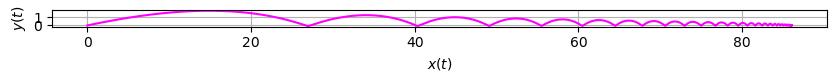

In [36]:
socc2_din.plot_rcomp()

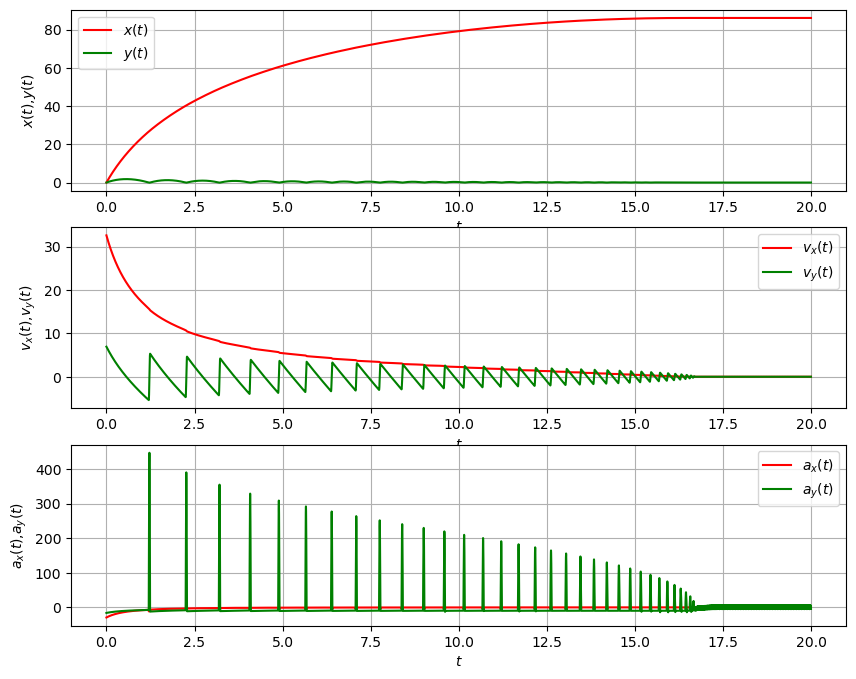

In [37]:
socc2_din.plot_rva_coord()

## 4. feladat:

a) Az előző pattogós labda modellben válaszolja meg, milyen magasan éri el a 120 km/h-val 12° alatt indított labda a kaput!

b) Rajzolja ki a kapu elérésnek magasságát ebben a modellben az elrúgás szögének függvényében.

c) Keresse ki azokat az elrúgási szögeket, mely esetén a kapi elérésnek magasága kb. 0.5 m! (Több megoldás!)

# Modell rakéta dinamikája

Modell rakéta: 
    
    * m_s saját tömeg
    * m_h hajtóanyag tömeg
    * v_h hajtóanyag sebesség
    * dmdt kiáramló hajtóanyag mennyiség időegységenként
    * C közegellenállási tényező
    * A mozgásirányú keresztmetszet
    
Generált tolóerő: lendületmegmaradásból. F_t = dmdt * v_h, de csak m_h/dmdt ideig; közben fogy a tömeg!

In [38]:
# rakétamodell tömeg- és erőfüggvéye
def create_rocket_F_m(C, A, rho, m_s, m_h, v_h, dmdt, g=9.81):

    # konstans tömeg
    def mass_fun(t):   
        return np.maximum(m_s, m_s+m_h-dmdt*t)   # tömeg lineárisan csökken m_s+m_h-ról másodpercenként dmdt-nyit, de m_s alá nem megy

    def force_fun(t, r, v, m):  
        """Gravitációs erő y irányban és v^2-tel arányos közegellenállási erő eredője
        + rakéta tolóerő."""
        
        F_work=np.array([0.0, -m*g], np.float64)  # grav erő
        v_abs=((v**2).sum())**0.5
        F_work-=0.5*C*A*rho*v*v_abs # közegell. erő hatása

        # tolóerő hatása:
        F_t=dmdt*v_h      # tolóerő nagyság
        t_max=m_h/dmdt  # eddig hat tolóerő

        if t<=t_max:   # van tolóerő
            F_work+=F_t*v/np.maximum(v_abs, 1e-10)
        
        return F_work

    return force_fun, mass_fun

In [39]:
# az előzőekhez hasonlóan

m_s=0.1
m_h=0.5
dmdt=0.2
v_h=80.0

r=0.02  # 2 cm sugarú rakétatest
A=np.pi*r**2
C=0.25  #   áramvonalas orr
rho=1.3 # levegő sűrűség

F_rocket, m_rocket=create_rocket_F_m(C, A, rho, m_s, m_h, v_h, dmdt, g=9.81)

# kezdőfeltétel
v0=1.0  # kell egy induló sebesség
alpha_deg=82.0  # induló irány

x0=0.0
y0=0.0
v0_x=v0*np.cos(np.radians(alpha_deg))
v0_y=v0*np.sin(np.radians(alpha_deg))


In [40]:
rocket_din=num_dinam(2)
rocket_din.set_time_range(0.0, 100.0, 0.01)  # jó hosszú időt adunk meg. majd a talaj megfogja....
rocket_din.set_mass_fun(m_rocket)
rocket_din.set_F_fun(F_rocket)   
rocket_din.set_r0_v0([x0, y0], [v0_x, v0_y])

rocket_din.stop_cond=stop_ground_y

rocket_din.full_dinam_calc()

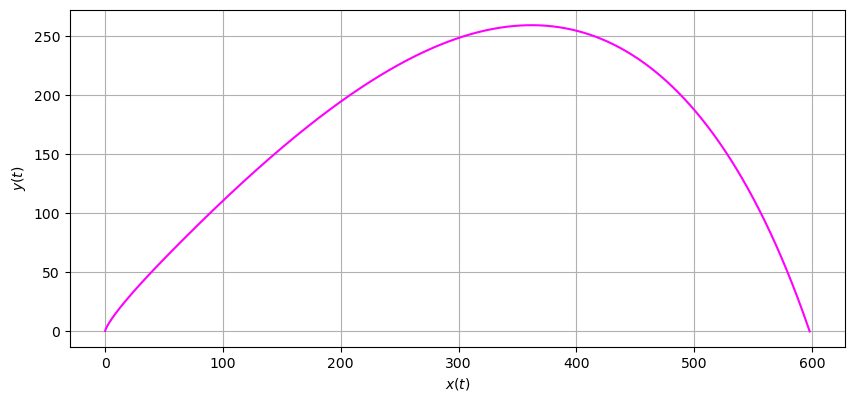

In [41]:
rocket_din.plot_rcomp()

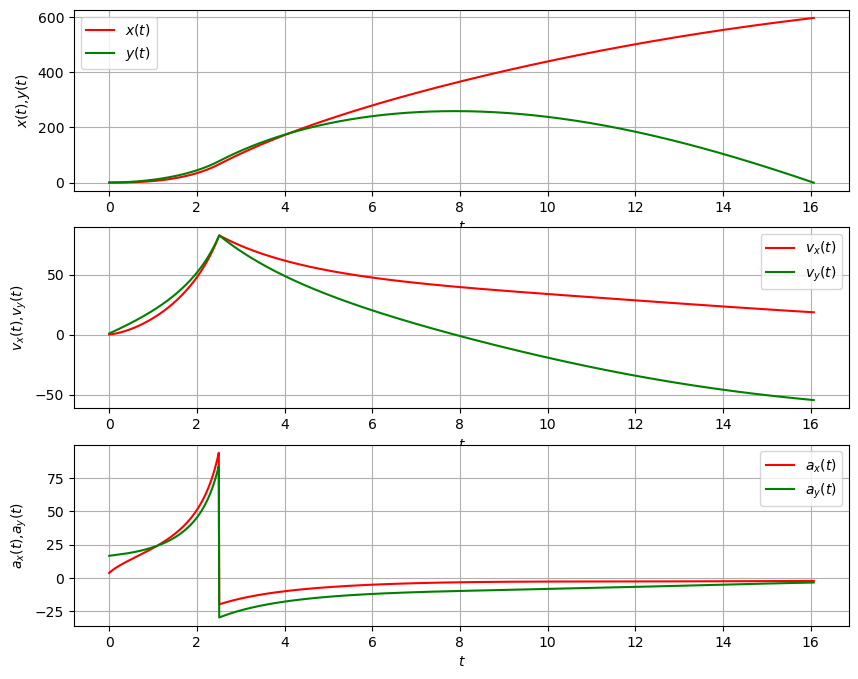

In [42]:
# koordináták az iodő függvényében
rocket_din.plot_rva_coord()

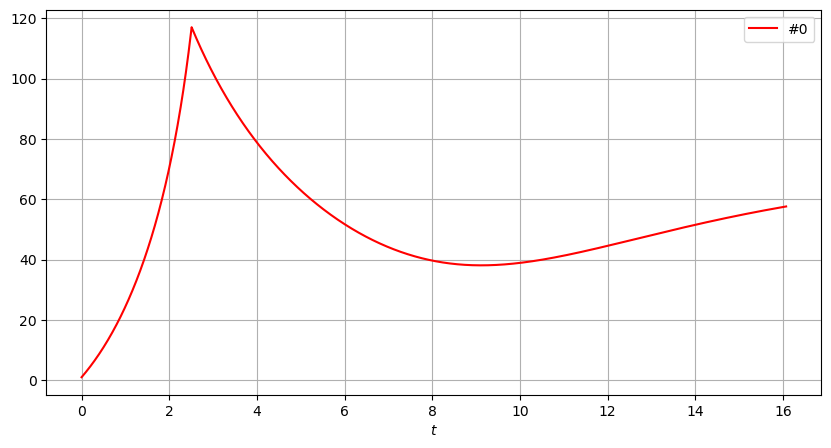

In [43]:
# sebesség nagysága az idő függvényében
rocket_din.vabs=vect_abs(rocket_din.v)
rocket_din.plot_simple([rocket_din.vabs])

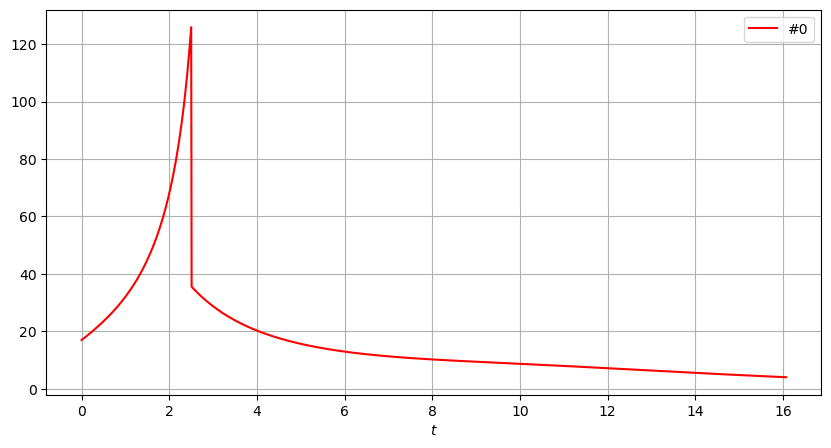

In [44]:
# gyorsulás nagysága az idő függvényében
rocket_din.aabs=vect_abs(rocket_din.a)
rocket_din.plot_simple([rocket_din.aabs])

## 5. feladat:

a) Ábrázolja a fenti modellben az ellövés szögének függvényében a rakéta által elért maximális magasságot és távolságot!

b) Milyen ellövési szög esetén lesz maximális az ellövési távolság?

c) Határozza meg a b) pontban kapott ellövési szöget használva, hogyan függ az ellövési távolság a hajtóanyag tömegétől. A hajtóanyag tömegét 0.0 és 3.0 kg közt, 0.01 kg-os lépésekben változtassa!

d) Mi az optimális hajtóanyag tömeg, ha a legnagyobb lövési távolságot szeretnénk elérni?


# Rezgések szimulációja

Csak más erőfüggvény kell, és leírhatjuk a rezgéseket is.

### Egyszerű harmonikus rezgés

In [45]:
# harmonikus rezgés, legegyszerűbb eset
def create_simple_spring_F_m(m, D):

    # konstans tömeg
    def mass_fun(t):   
        return m

    def force_fun(t, r, v, m): 
                
        F_work=-D*r  # rugóerő       
        return F_work

    return force_fun, mass_fun

In [64]:
m=0.15
D=0.4  # Vagy: D=np.array([0.4, 0.3]), ha iránytól függő D-t akarunk
F_spring, m_body=create_simple_spring_F_m(m, D)

# kezdő feltétlek:
r0=np.array([0.1, 0.0], np.float64)
v0=np.array([0.3, 0.0], np.float64)

# modell
spring=num_dinam(2)   # engedjük síkban is mozogni

spring.set_time_param(0.0, 20.0, 0.001)
spring.set_mass_fun(m_body)
spring.set_F_fun(F_spring)   
spring.set_r0_v0(r0, v0)

spring.full_dinam_calc()

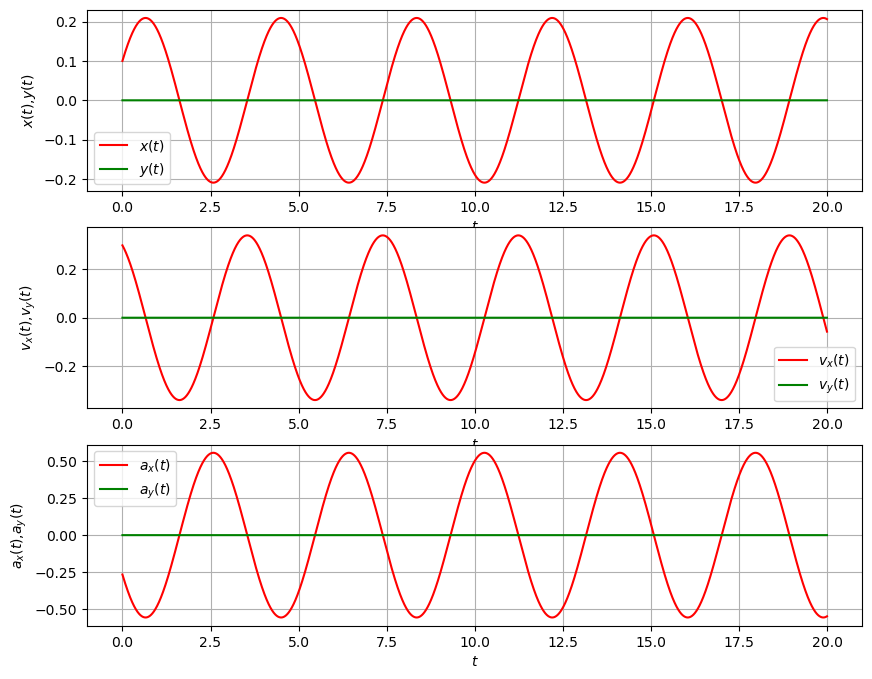

In [65]:
# hely, sebesség, és gyorsulás komponensek:
spring.plot_rva_coord()

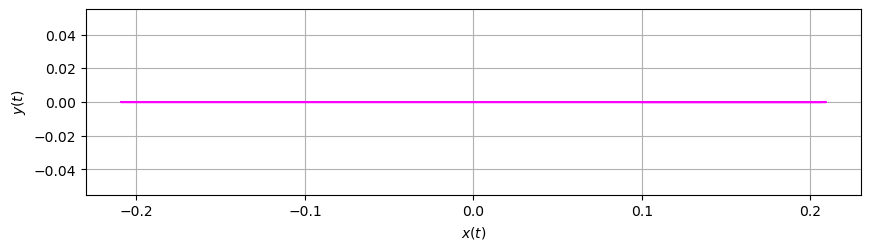

In [66]:
# pálya: lehet, hogy egyenes:
spring.plot_rcomp()
# Ha y irányban is meglökjük, akkor síkbeli mozgás lesz

## 6. feladat:

Adjunk Y irányú kezdősebességet is a mozgásnak és nézzük meg, mi történik.

### Harmonikus rezgés lineáris közegellenállással

In [67]:
# rugóerő + lineáris közegellenállás C*v nagyságú erővel
def create_spring_medium_F_m(m, D, C):

    # konstans tömeg
    def mass_fun(t):   
        return m

    def force_fun(t, r, v, m): 
                
        F_work=-D*r  # rugóerő       
        
        # közegellenállás: hasonlóan mint korábban
        F_work-=C*v# közegell. erő hatása, lineáris v-vel
        
        return F_work

    return force_fun, mass_fun

In [68]:
m=0.15
D=0.4
C=0.01
F_spring_m, m_body=create_spring_medium_F_m(m, D, C)

# kezdő feltételek: (mint az előbb)
r0=np.array([0.1, 0.0], np.float64)
v0=np.array([0.3, 0.0], np.float64)

# modell
spring_m=num_dinam(2)   # engedjük síkban is mozogni

spring_m.set_time_param(0.0, 20.0, 0.001)
spring_m.set_mass_fun(m_body)
spring_m.set_F_fun(F_spring_m)     # megfelelő erőfüggvény!
spring_m.set_r0_v0(r0, v0)

spring_m.full_dinam_calc()

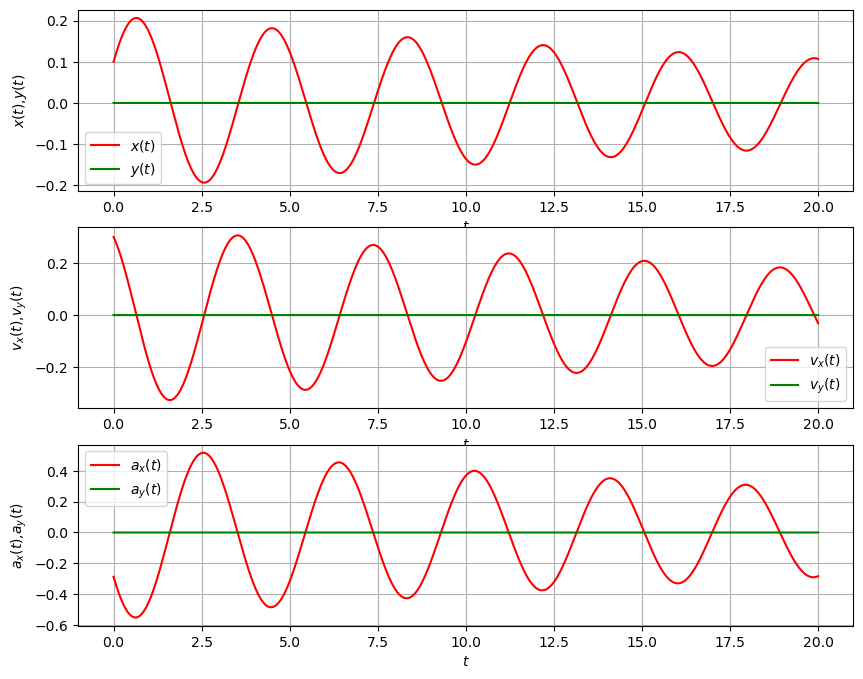

In [69]:
# hely, sebesség, és gyorsulás komponensek:
spring_m.plot_rva_coord()

Lassan csökken az amplitúdó!

Hogyan mérjük meg?

In [70]:
# Max. kitérések keresése: v_x=0
ind_vx0=arg_eq(spring_m.v[:,0], 0.0)

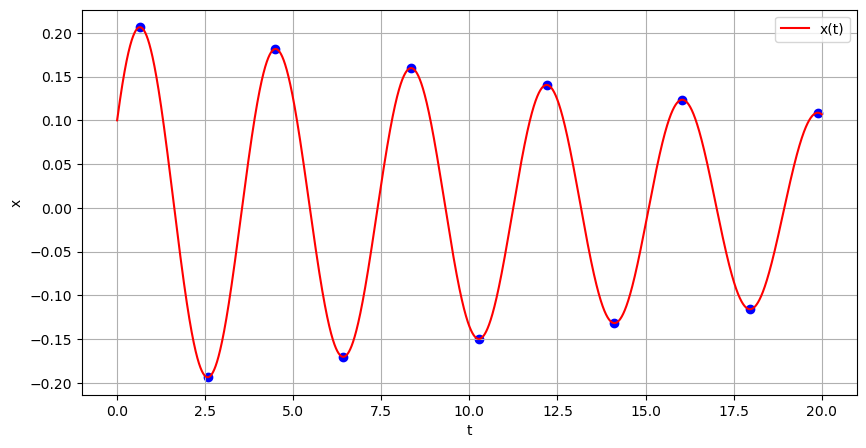

In [71]:
fig=plt.figure(figsize=(10,5))  

ax1=fig.add_subplot(111) 

ax1.plot(spring_m.t, spring_m.r[:,0], color="red", label="x(t)")
ax1.scatter(spring_m.t[ind_vx0], spring_m.r[ind_vx0,0], color="blue",)
ax1.set_xlabel("t") 
ax1.set_ylabel("x") 
ax1.legend(loc="best")
ax1.grid()    



In [72]:
# max kitérések nagysága:

print("A legnagyobb kitérések értékei: ", spring_m.r[ind_vx0, 0])

A legnagyobb kitérések értékei:  [ 0.20637082 -0.19354938  0.18152449 -0.17024673  0.15966964 -0.14974968
  0.140446   -0.13172034  0.1235368  -0.11586171  0.10866345]


## 7. feladat:

Mérjük meg a rezgés periódusidejét és hasonlítsuk össze az elméleti értékkel!